# Importations et Préparation

In [ ]:
import os
import glob
from pathlib import Path
from typing import List, Tuple, Optional, Dict, Any
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn import preprocessing, model_selection, metrics
from tqdm import tqdm

# Outils pour le dataset et le modèle
from torch import nn
from torch.nn import functional as F
import albumentations

print(f"Prêt à travailler sur : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

Prêt à travailler sur : CPU


# Configuration et Hyperparamètres

In [5]:
# Chemins et paramètres
DATA_DIR = "C:/Users/htalbi/workspace/projet_API/data/captcha_images_v2" 

BATCH_SIZE = 8         # Nombre d'images traitées à la fois
IMAGE_WIDTH = 300      # Largeur cible pour le modèle
IMAGE_HEIGHT = 75      # Hauteur cible pour le modèle
EPOCHS = 50            # Nombre de cycles d'entraînement
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# On s'assure que le dossier existe
if not os.path.exists(DATA_DIR):
    print(f"⚠️ Attention : Le dossier {DATA_DIR} est introuvable.")

# Chargement et Préparation des Étiquettes (Labels)

In [6]:
def load_data(data_dir: str) -> Tuple[List[str], List[str], List[str]]:
    """
    Liste les chemins des images et extrait les labels des noms de fichiers.
    
    Args:
        data_dir: Chemin vers le dossier contenant les images.
        
    Returns:
        Un triplet (chemins_images, labels, vocabulaire).
    """
    # Récupération des chemins (ex: images_v2/2g4pv.png)
    images: List[str] = sorted(glob.glob(os.path.join(data_dir, "*.png")))
    
    # Extraction du label (nom du fichier sans extension)
    labels: List[str] = [os.path.splitext(os.path.basename(x))[0] for x in images]
    
    # Création du vocabulaire unique
    characters: List[str] = sorted(list(set("".join(labels))))
    
    return images, labels, characters

# Chargement
image_paths, labels, vocab = load_data(DATA_DIR)

print(f"Nombre d'images : {len(image_paths)}")
print(f"Vocabulaire ({len(vocab)} caractères) : {vocab}")

Nombre d'images : 1040
Vocabulaire (19 caractères) : ['2', '3', '4', '5', '6', '7', '8', 'b', 'c', 'd', 'e', 'f', 'g', 'm', 'n', 'p', 'w', 'x', 'y']


# Le Dataset PyTorch

In [7]:
from torch.utils.data import Dataset


class CaptchaDataset(Dataset):
    """
    Dataset personnalisé pour charger les images de CAPTCHA et leurs labels encodés.
    """
    def __init__(
        self, 
        image_paths: List[str], 
        targets: List[List[int]], 
        resize: Tuple[int, int]
    ) -> None:
        """
        Initialise le dataset avec les chemins, les cibles et la taille cible.
        """
        self.image_paths = image_paths
        self.targets = targets
        self.resize = resize # (Hauteur, Largeur)
        
        # Normalisation standard ImageNet
        self.aug = albumentations.Compose([
            albumentations.Normalize(
                mean=(0.485, 0.456, 0.406), 
                std=(0.229, 0.224, 0.225), 
                always_apply=True
            )
        ])

    def __len__(self) -> int:
        """Retourne le nombre total d'exemples."""
        return len(self.image_paths)

    def __getitem__(self, item: int) -> Dict[str, torch.Tensor]:
        """
        Récupère un échantillon (image + label) par son index.
        """
        # Chargement et conversion RGB
        image = Image.open(self.image_paths[item]).convert("RGB")
        
        # Redimensionnement
        image = image.resize((self.resize[1], self.resize[0]), resample=Image.BILINEAR)
        image = np.array(image)
        
        # Augmentation/Normalisation
        augmented = self.aug(image=image)
        image = augmented["image"]
        
        # Conversion format PyTorch (H, W, C) -> (C, H, W)
        image = np.transpose(image, (2, 0, 1)).astype(np.float32)
        
        return {
            "images": torch.tensor(image, dtype=torch.float),
            "targets": torch.tensor(self.targets[item], dtype=torch.long),
        }

# Encodage et Visualisation d'un exemple

In [8]:
# 1. Création du dictionnaire de caractères (Mapping)
# On commence à l'indice 1 pour laisser le 0 au caractère spécial "blank" (vide)
char_to_num: Dict[str, int] = {char: idx + 1 for idx, char in enumerate(vocab)}
num_to_char: Dict[int, str] = {idx: char for char, idx in char_to_num.items()}

def encode_label(label: str, mapping: Dict[str, int]) -> List[int]:
    """
    Transforme une chaîne de caractères en une liste d'entiers.
    
    Args:
        label: Le texte du CAPTCHA (ex: "abc").
        mapping: Le dictionnaire de conversion caractère -> nombre.
    """
    return [mapping[c] for c in label]

# 2. Conversion de tous les labels du projet
targets: List[List[int]] = [encode_label(l, char_to_num) for l in labels]

# 3. Création du dataset d'entraînement
full_dataset = CaptchaDataset(
    image_paths=image_paths,
    targets=targets,
    resize=(IMAGE_HEIGHT, IMAGE_WIDTH)
)

# 4. Fonction pour afficher une image "dé-normalisée"
def show_processed_sample(dataset: CaptchaDataset, index: int) -> None:
    """
    Affiche une image du dataset en inversant la normalisation pour l'œil humain.
    """
    sample: Dict[str, torch.Tensor] = dataset[index]
    img_tensor = sample["images"]
    target_indices = sample["targets"]
    
    # Passage du format PyTorch (C, H, W) au format image (H, W, C)
    img = img_tensor.numpy().transpose(1, 2, 0)
    
    # Inversion de la normalisation ImageNet
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    
    plt.figure(figsize=(8, 4))
    plt.imshow(img)
    plt.title(f"Texte original : {labels[index]}\nSéquence numérique (Target) : {target_indices.tolist()}")
    plt.axis("off")
    plt.show()

C:\Users\htalbi\AppData\Local\Temp\ipykernel_28884\3650636790.py:23: UserWarning: Argument(s) 'always_apply' are not valid for transform Normalize
  albumentations.Normalize(


In [11]:
def print_dictionary_mapping(mapping: Dict[str, int]) -> None:
    """
    Affiche proprement la correspondance entre lettres et chiffres.
    """
    print("Dictionnaire de traduction :")
    # On trie par valeur pour plus de clarté
    for char, value in sorted(mapping.items(), key=lambda item: item[1]):
        print(f"  '{char}'  ----->  {value}")

print_dictionary_mapping(char_to_num)

Dictionnaire de traduction :
  '2'  ----->  1
  '3'  ----->  2
  '4'  ----->  3
  '5'  ----->  4
  '6'  ----->  5
  '7'  ----->  6
  '8'  ----->  7
  'b'  ----->  8
  'c'  ----->  9
  'd'  ----->  10
  'e'  ----->  11
  'f'  ----->  12
  'g'  ----->  13
  'm'  ----->  14
  'n'  ----->  15
  'p'  ----->  16
  'w'  ----->  17
  'x'  ----->  18
  'y'  ----->  19


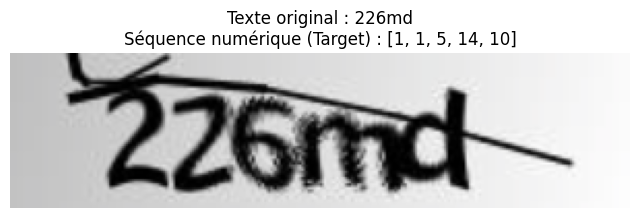

In [9]:
# Test sur le premier exemple
show_processed_sample(full_dataset, 0)

# L'Architecture du Modèle (CNN + RNN)

In [12]:
class CaptchaModel(nn.Module):
    """
    Modèle hybride CRNN (CNN + RNN) pour la reconnaissance de caractères.
    """
    def __init__(self, num_chars: int) -> None:
        """
        Initialise les couches du modèle.
        
        Args:
            num_chars: Nombre de caractères uniques dans le dictionnaire.
        """
        super().__init__()

        # 1. Extraction de caractéristiques (CNN)
        # Bloc 1 : Détecte les formes simples
        self.conv_1: nn.Conv2d = nn.Conv2d(3, 128, kernel_size=(3, 6), padding=(1, 1))
        self.pool_1: nn.MaxPool2d = nn.MaxPool2d(kernel_size=(2, 2))

        # Bloc 2 : Détecte les formes complexes
        self.conv_2: nn.Conv2d = nn.Conv2d(128, 64, kernel_size=(3, 6), padding=(1, 1))
        self.pool_2: nn.MaxPool2d = nn.MaxPool2d(kernel_size=(2, 2))

        # 2. Transition vers le RNN
        # Réduit la dimension avant d'entrer dans la séquence
        self.linear_1: nn.Linear = nn.Linear(1152, 64)
        self.drop_1: nn.Dropout = nn.Dropout(0.2)

        # 3. Analyse de la séquence (RNN)
        # Utilise un GRU bidirectionnel pour lire de gauche à droite ET de droite à gauche
        self.lstm: nn.GRU = nn.GRU(
            input_size=64,
            hidden_size=32,
            bidirectional=True,
            num_layers=2,
            dropout=0.25,
            batch_first=True,
        )

        # 4. Couche de sortie
        # num_chars + 1 pour inclure le caractère spécial "blank"
        self.output: nn.Linear = nn.Linear(64, num_chars + 1)

    def forward(
        self, 
        images: torch.Tensor, 
        targets: Optional[torch.Tensor] = None
    ) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        """
        Définit le passage des données dans le réseau.
        
        Args:
            images: Batch d'images de taille (B, 3, H, W).
            targets: Labels encodés (optionnel).
            
        Returns:
            Logits (prédictions brutes) et la perte (loss) si targets est fourni.
        """
        bs: int = images.size(0)

        # Passage dans les convolutions
        x: torch.Tensor = F.relu(self.conv_1(images))
        x = self.pool_1(x)
        x = F.relu(self.conv_2(x))
        x = self.pool_2(x)

        # Préparation pour le RNN : on transforme l'image en séquence
        # On veut que la largeur (W) devienne notre dimension temporelle
        x = x.permute(0, 3, 1, 2)  # (B, C, H, W) -> (B, W, C, H)
        x = x.view(bs, x.size(1), -1) 

        x = F.relu(self.linear_1(x))
        x = self.drop_1(x)

        # Passage dans le GRU
        x, _ = self.lstm(x)

        # Calcul des prédictions finales
        x = self.output(x)
        
        # Formatage pour la perte CTC (Largeur, Batch, Classes)
        x = x.permute(1, 0, 2)

        if targets is not None:
            # On utilise ici la CTC Loss interne
            log_probs = F.log_softmax(x, dim=2)
            input_lengths = torch.full(size=(bs,), fill_value=log_probs.size(0), dtype=torch.int32).to(DEVICE)
            target_lengths = torch.full(size=(bs,), fill_value=targets.size(1), dtype=torch.int32).to(DEVICE)
            loss = nn.CTCLoss(blank=0)(log_probs, targets, input_lengths, target_lengths)
            return x, loss

        return x, None

# Le Traducteur Inverse (Décodage CTC)

In [13]:
def remove_duplicates(text: str) -> str:
    """
    Supprime les caractères consécutifs identiques (règle CTC).
    Exemple : "22266mmd" -> "26md"
    """
    if len(text) < 2:
        return text

    result: str = ""
    for char in text:
        if result == "" or char != result[-1]:
            result += char
    return result

def decode_predictions(preds: torch.Tensor, mapping: Dict[int, str]) -> List[str]:
    """
    Transforme les sorties brutes du modèle en texte lisible.
    """
    # On prend l'indice du caractère ayant le plus haut score
    preds = preds.permute(1, 0, 2) # (T, B, C) -> (B, T, C)
    preds = torch.softmax(preds, 2)
    preds = torch.argmax(preds, 2)
    preds = preds.detach().cpu().numpy()

    final_outputs: List[str] = []

    for b in range(preds.shape[0]):
        temp: List[str] = []
        for k in preds[b, :]:
            k = k - 1 # On enlève le décalage du blank
            if k == -1:
                temp.append("§") # Symbole temporaire pour le blank
            else:
                temp.append(mapping[k + 1]) # On retrouve la lettre

        # On nettoie : on enlève les blanks et on fusionne les doublons
        clean_text = "".join(temp).replace("§", "")
        final_outputs.append(remove_duplicates(clean_text))

    return final_outputs

# L'Entraînement et l'Évaluation

In [17]:
from sklearn import model_selection
from tqdm import tqdm

# 1. Préparation des données et du modèle
train_imgs, test_imgs, train_targets, test_targets = model_selection.train_test_split(
    image_paths, targets, test_size=0.1, random_state=42
)

train_loader = torch.utils.data.DataLoader(
    CaptchaDataset(train_imgs, train_targets, (IMAGE_HEIGHT, IMAGE_WIDTH)),
    batch_size=BATCH_SIZE, shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    CaptchaDataset(test_imgs, test_targets, (IMAGE_HEIGHT, IMAGE_WIDTH)),
    batch_size=BATCH_SIZE, shuffle=False
)

model = CaptchaModel(num_chars=len(vocab))
model.to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.8, patience=5)

# 2. La grande boucle d'apprentissage
for epoch in range(EPOCHS):
    # --- PHASE D'ENTRAÎNEMENT ---
    model.train() # Active le dropout
    train_loss = 0.0
    tk0 = tqdm(train_loader, total=len(train_loader), desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    
    for data in tk0:
        for key, value in data.items():
            data[key] = value.to(DEVICE)
        
        optimizer.zero_grad() # Reset des gradients
        _, loss = model(**data) # Forward pass
        loss.backward() # Calcul des gradients
        optimizer.step() # Mise à jour des poids
        train_loss += loss.item()
        tk0.set_postfix(loss=loss.item())

    # --- PHASE DE VALIDATION ---
    model.eval() # Désactive le dropout
    valid_loss = 0.0
    with torch.no_grad(): # Pas de calcul de gradient pour gagner du temps
        tk1 = tqdm(test_loader, total=len(test_loader), desc=f"Epoch {epoch+1}/{EPOCHS} [Valid]")
        for data in tk1:
            for key, value in data.items():
                data[key] = value.to(DEVICE)
            _, loss = model(**data)
            valid_loss += loss.item()
            tk1.set_postfix(loss=loss.item())

    avg_train_loss = train_loss / len(train_loader)
    avg_valid_loss = valid_loss / len(test_loader)
    
    print(f"Summary -> Train Loss: {avg_train_loss:.4f} | Valid Loss: {avg_valid_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")
    scheduler.step(avg_valid_loss) # Ajuste le LR si la perte stagne

C:\Users\htalbi\AppData\Local\Temp\ipykernel_28884\3650636790.py:23: UserWarning: Argument(s) 'always_apply' are not valid for transform Normalize
  albumentations.Normalize(
Epoch 1/50 [Train]:   0%|          | 0/117 [00:00<?, ?it/s]

Epoch 1/50 [Valid]: 100%|██████████| 13/13 [00:03<00:00,  3.74it/s, loss=3.32]


Summary -> Train Loss: 7.6570 | Valid Loss: 3.3174 | LR: 0.000300


Epoch 2/50 [Valid]: 100%|██████████| 13/13 [00:01<00:00,  6.55it/s, loss=3.33]


Summary -> Train Loss: 3.2872 | Valid Loss: 3.2923 | LR: 0.000300


...

Summary -> Train Loss: 0.1516 | Valid Loss: 0.1236 | LR: 0.000240


Epoch 49/50 [Valid]: 100%|██████████| 13/13 [00:02<00:00,  5.42it/s, loss=0.0731]


Summary -> Train Loss: 0.1413 | Valid Loss: 0.1163 | LR: 0.000240


Epoch 50/50 [Valid]: 100%|██████████| 13/13 [00:02<00:00,  6.47it/s, loss=0.0625]

Summary -> Train Loss: 0.1338 | Valid Loss: 0.1208 | LR: 0.000240


# Inférence et Visualisation des résultats

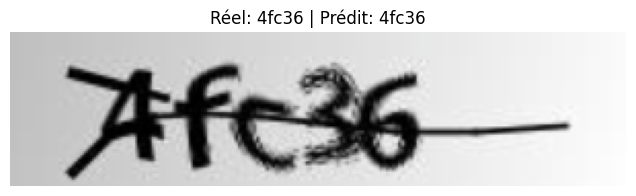

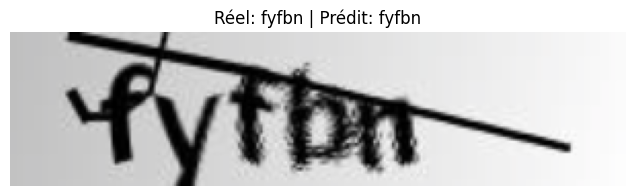

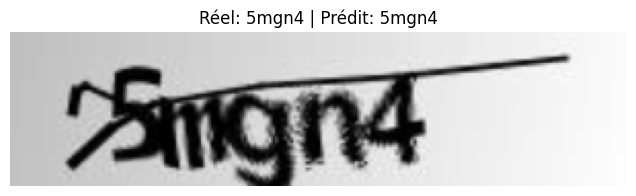

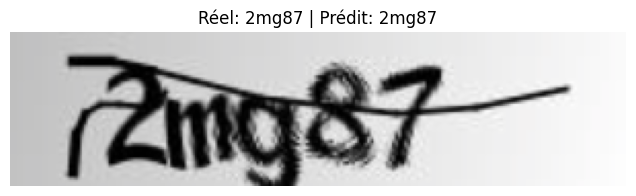

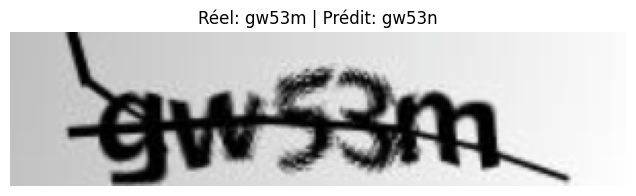

In [18]:
def visualize_predictions(
    model: torch.nn.Module, 
    test_loader: torch.utils.data.DataLoader, 
    mapping: Dict[int, str], 
    num_images: int = 5
) -> None:
    """
    Prend un échantillon d'images du jeu de test, prédit le texte et les affiche.
    
    Args:
        model: Le modèle entraîné.
        test_loader: Le chargeur de données de test.
        mapping: Le dictionnaire pour convertir les chiffres en lettres.
        num_images: Nombre d'images à afficher.
    """
    model.eval() # Désactive le dropout pour la prédiction
    images_shown = 0
    
    # On ne calcule pas les gradients ici (gain de mémoire et vitesse)
    with torch.no_grad():
        for data in test_loader:
            # Envoi des données sur le GPU/CPU
            images = data["images"].to(DEVICE)
            targets = data["targets"]
            
            # Le modèle nous donne les scores (logits)
            batch_preds, _ = model(images)
            
            # On utilise notre logique de décodage
            # Rappel : decode_predictions doit être définie ou importée
            current_preds = decode_predictions(batch_preds, mapping)
            
            # Conversion des targets (réel) en texte lisible pour comparer
            real_texts = []
            for t in targets:
                t_list = t.numpy().tolist()
                # On décode les targets en ignorant le blank (0)
                real_texts.append("".join([mapping[i] for i in t_list if i != 0]))

            # Affichage avec Matplotlib
            for i in range(images.size(0)):
                if images_shown >= num_images:
                    return
                
                img = images[i].cpu().numpy().transpose(1, 2, 0)
                # Inversion de la normalisation pour l'affichage
                mean = [0.485, 0.456, 0.406]
                std = [0.229, 0.224, 0.225]
                img = std * img + mean
                img = img.clip(0, 1)
                
                plt.figure(figsize=(10, 2))
                plt.imshow(img)
                plt.title(f"Réel: {real_texts[i]} | Prédit: {current_preds[i]}")
                plt.axis("off")
                plt.show()
                
                images_shown += 1

# On lance la visualisation sur 5 images du jeu de test
visualize_predictions(model, test_loader, num_to_char, num_images=5)

# Calcul de l'Accuracy globale

In [19]:
def calculate_accuracy(model: torch.nn.Module, loader: torch.utils.data.DataLoader) -> float:
    """
    Calcule le pourcentage de CAPTCHAs parfaitement résolus sur un dataset.
    """
    model.eval() # Mode évaluation
    all_preds: List[str] = []
    all_targets: List[str] = []
    
    with torch.no_grad():
        for data in loader:
            images = data["images"].to(DEVICE)
            targets = data["targets"]
            
            # 1. Obtenir les prédictions du modèle
            batch_preds, _ = model(images)
            
            # 2. Décoder les prédictions en texte
            decoded_preds = decode_predictions(batch_preds, num_to_char)
            all_preds.extend(decoded_preds)
            
            # 3. Décoder les cibles (targets) réelles pour la comparaison
            for t in targets:
                target_indices = t.numpy().tolist()
                # On ignore le blank (0) et on convertit les chiffres en lettres
                real_text = "".join([num_to_char[i] for i in target_indices if i != 0])
                all_targets.append(real_text)
    
    # 4. Calcul du score final (strict : égalité parfaite des chaînes)
    accuracy = metrics.accuracy_score(all_targets, all_preds)
    return accuracy

# Calcul et affichage
final_acc = calculate_accuracy(model, test_loader)
print(f"✅ Accuracy finale sur le jeu de test : {final_acc * 100:.2f}%")

✅ Accuracy finale sur le jeu de test : 67.31%


# Sauvegarde du Modèle et des Métadonnées

In [20]:
import joblib # Utile pour sauvegarder des dictionnaires ou objets Python

# 1. Définition des noms de fichiers
MODEL_PATH = "captcha_model.pth"
MAPPING_PATH = "mapping.joblib"

# 2. Sauvegarde des poids du modèle
# On sauvegarde le 'state_dict' qui contient tous les paramètres ajustés par l'optimiseur
torch.save(model.state_dict(), MODEL_PATH)

# 3. Sauvegarde du dictionnaire de correspondance
# On enregistre le vocabulaire pour garantir que les futurs décodages soient identiques
metadata = {
    "char_to_num": char_to_num,
    "num_to_char": num_to_char,
    "vocab": vocab
}
joblib.dump(metadata, MAPPING_PATH)

print(f"✅ Modèle sauvegardé dans : {MODEL_PATH}")
print(f"✅ Métadonnées sauvegardées dans : {MAPPING_PATH}")

✅ Modèle sauvegardé dans : captcha_model.pth
✅ Métadonnées sauvegardées dans : mapping.joblib
